# Detection - threshold diagnostic (per-channel selectivity)

Stage-1 chose threshold 6 for 100% IED recall - but recall there is "**any** channel fires within
+/-100 ms of the marker." This notebook checks whether that is *genuine per-channel detection* or is
**inflated because too many channels cross at the marker** (so the count of crossing channels overstates
the IED's true extent). Two questions:

1. **How many channels cross at the marker at threshold 6?** A focal IED lives on a handful of adjacent
   electrodes; if ~15 cross, most are spurious.
2. **Why?** Coincidence / low threshold (→ fixed by raising the threshold) vs **reference contamination**
   - a large IED leaking onto every channel via the shared reference (→ fixed by re-referencing, *not* by
   threshold). We test this by repeating everything under **average reference**: if it barely changes, the
   cause is the threshold, not the reference.

**Train-only:** this *selects* a threshold, so it runs on the **90-recording train split** (the 10 test
recordings must not influence the choice). It is a raw-crossing proxy; the correlation-based version
(consolidation, ">=2 *cross-correlated* channels") comes once Layer 2 exists.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt, mne
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_CSV
from detect_data import CH19, SF, load_dataset, stratified_split
from detect_stage1 import channel_stat, n_channels_crossing
Path('../figures').mkdir(exist_ok=True)

TOL = int(0.10 * SF)                       # +-100 ms
THRESHOLDS = [6, 8, 10, 12, 14, 16, 18, 20, 25, 30]

man = load_CSV(Path('..') / 'Kural_Dataset' / 'eeg_summary.csv')
train_df, _ = stratified_split(man, n_test=10, seed=0)     # 90 train; 10 test untouched
recs = load_dataset(train_df, Path('..') / 'Kural_Dataset' / 'Recordings')   # recorded reference
for r in recs:                                             # sharpness under both references
    r['stat_rec'] = channel_stat(r['X'], SF)
    r['stat_avg'] = channel_stat(r['X'] - r['X'].mean(0), SF)
ied = [r for r in recs if r['epi']]

short = [c.replace('E ', '').replace('-Ref', '').replace('FP', 'Fp') for c in CH19]
info = mne.create_info(short, SF, 'eeg'); info.set_montage('standard_1020')
print(f"{len(recs)} train recordings, {len(ied)} IEDs, {len(CH19)} channels")

90 train recordings, 49 IEDs, 19 channels


In [2]:
# How many channels cross at the marker at threshold 6 -- recorded vs average reference?
TH0 = 6
print(f"channels crossing within +/-100 ms of the IED marker, threshold {TH0} (of {len(CH19)}):")
for ref, key in [('recorded', 'stat_rec'), ('average', 'stat_avg')]:
    c = np.array([n_channels_crossing(r[key], TH0, r['mk'], TOL) for r in ied])
    print(f"  {ref:9s} ref: median {np.median(c):.0f}, mean {c.mean():.1f}, range [{c.min()},{c.max()}]")
print("\n(If average ~ recorded, the over-firing is a low-threshold effect, not reference contamination.)")

channels crossing within +/-100 ms of the IED marker, threshold 6 (of 19):
  recorded  ref: median 17, mean 15.4, range [2,19]
  average   ref: median 18, mean 16.3, range [6,19]

(If average ~ recorded, the over-firing is a low-threshold effect, not reference contamination.)


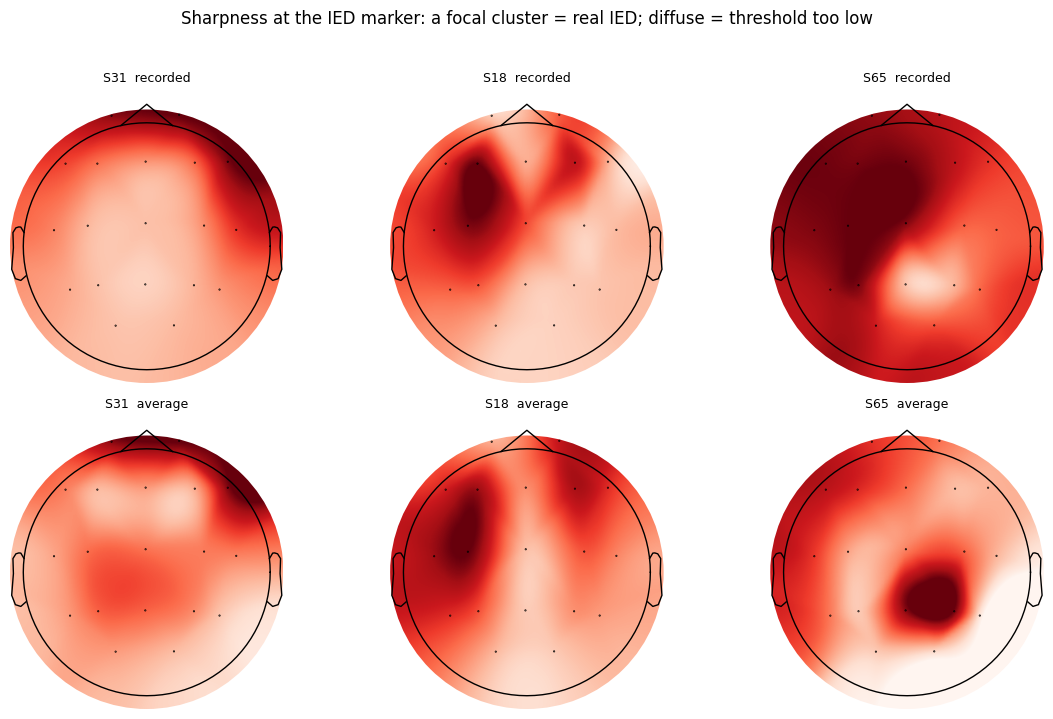

In [3]:
# Sharpness topography at the marker, 3 clear-positive IEDs: recorded (top) vs average (bottom)
ex = [r for r in ied if r['cert'] == 'clear_positive'][:3]
fig, axes = plt.subplots(2, len(ex), figsize=(4 * len(ex), 7))
for j, r in enumerate(ex):
    lo, hi = r['mk'] - TOL, r['mk'] + TOL
    for i, (ref, key) in enumerate([('recorded', 'stat_rec'), ('average', 'stat_avg')]):
        mne.viz.plot_topomap(r[key][:, lo:hi].max(1), info, axes=axes[i, j], show=False,
                             cmap='Reds', contours=0)
        axes[i, j].set_title(f"{r['fid']}  {ref}", fontsize=9)
plt.suptitle('Sharpness at the IED marker: a focal cluster = real IED; diffuse = threshold too low', y=1.02)
plt.tight_layout()
plt.savefig('../figures/detection_threshold_topomap.png', dpi=800, bbox_inches='tight')
plt.show()

 th recall_ge2 recall_ge3 med_marker med_bg
  6       1.00       0.98         17      5
  8       0.94       0.92         12      0
 10       0.84       0.82          8      0
 12       0.78       0.65          6      0
 14       0.63       0.57          4      0
 16       0.57       0.49          2      0
 18       0.51       0.45          2      0
 20       0.47       0.37          1      0
 25       0.39       0.29          0      0
 30       0.31       0.20          0      0


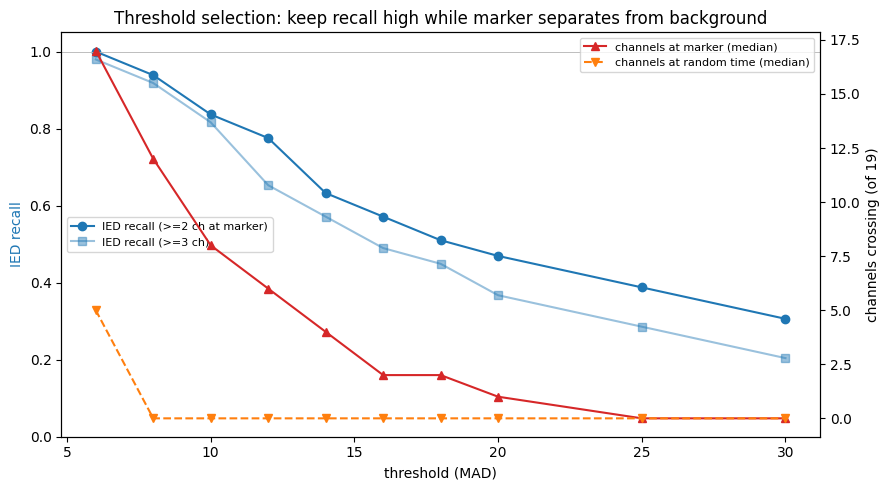

In [4]:
# Marker vs random-time channel-crossing gap over the threshold sweep (recorded reference)
rng = np.random.default_rng(0)
def bg_counts(r, th, n=30):
    T = r['stat_rec'].shape[1]; out = []
    for _ in range(n):
        t0 = int(rng.integers(TOL, T - TOL))
        if abs(t0 - r['mk']) < int(0.5 * SF):           # keep background clear of the marker
            continue
        out.append(n_channels_crossing(r['stat_rec'], th, t0, TOL))
    return out

rows = []
for th in THRESHOLDS:
    marker = [n_channels_crossing(r['stat_rec'], th, r['mk'], TOL) for r in ied]
    bg = [c for r in recs for c in bg_counts(r, th)]
    rows.append(dict(th=th, recall_ge2=np.mean([m >= 2 for m in marker]),
                     recall_ge3=np.mean([m >= 3 for m in marker]),
                     med_marker=np.median(marker), med_bg=np.median(bg)))
sw = pd.DataFrame(rows)
print(sw.to_string(index=False, formatters={'recall_ge2': '{:.2f}'.format, 'recall_ge3': '{:.2f}'.format,
                                             'med_marker': '{:.0f}'.format, 'med_bg': '{:.0f}'.format}))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sw.th, sw.recall_ge2, 'o-', color='C0', label='IED recall (>=2 ch at marker)')
ax.plot(sw.th, sw.recall_ge3, 's-', color='C0', alpha=0.45, label='IED recall (>=3 ch)')
ax.axhline(1.0, color='0.7', lw=0.6); ax.set_ylim(0, 1.05)
ax.set_xlabel('threshold (MAD)'); ax.set_ylabel('IED recall', color='C0')
ax2 = ax.twinx()
ax2.plot(sw.th, sw.med_marker, '^-', color='C3', label='channels at marker (median)')
ax2.plot(sw.th, sw.med_bg, 'v--', color='C1', label='channels at random time (median)')
ax2.set_ylabel('channels crossing (of 19)')
ax.legend(loc='center left', fontsize=8); ax2.legend(loc='upper right', fontsize=8)
plt.title('Threshold selection: keep recall high while marker separates from background')
plt.tight_layout()
plt.savefig('../figures/detection_threshold_sweep.png', dpi=800, bbox_inches='tight')
plt.show()

In [5]:
ok = sw[sw.recall_ge2 >= 1.0]
pick = ok.iloc[int(ok.th.argmax())] if len(ok) else sw.iloc[int(sw.recall_ge2.argmax())]
print(f"Highest threshold with 100% IED recall at >=2 channels: {pick.th:.0f}")
print(f"  median channels at marker {pick.med_marker:.0f} vs {pick.med_bg:.0f} at random time  "
      f"(separation {pick.med_marker - pick.med_bg:+.0f})")
print()
print("Reads:")
print(" - crossing-dist cell: if average ~ recorded -> raise the threshold, don't re-reference.")
print(" - sweep: pick the highest threshold where recall stays 1.0 AND the marker curve sits")
print("   clearly above the random-time curve (below that, you can't tell IED firing from coincidence).")
print(" - proxy only: raw crossings; re-confirm with correlation-based consolidation once Layer 2 exists.")

Highest threshold with 100% IED recall at >=2 channels: 6
  median channels at marker 17 vs 5 at random time  (separation +12)

Reads:
 - crossing-dist cell: if average ~ recorded -> raise the threshold, don't re-reference.
 - sweep: pick the highest threshold where recall stays 1.0 AND the marker curve sits
   clearly above the random-time curve (below that, you can't tell IED firing from coincidence).
 - proxy only: raw crossings; re-confirm with correlation-based consolidation once Layer 2 exists.
